# 02 — Feature Engineering
### House Price Prediction · Ames Housing Dataset

---

## Mengapa Feature Engineering penting?

Di notebook sebelumnya kita sudah punya model yang berjalan — tapi kita belum **benar-benar memahami data**. Feature Engineering adalah proses mengubah data mentah menjadi representasi yang lebih bermakna bagi model.

Secara sederhana: **model hanya sebaik fitur yang diberikan kepadanya.**

Di notebook ini kita akan:
1. Mendeteksi dan menangani **outlier** secara proper
2. Membuat **fitur baru** yang lebih informatif dari kombinasi fitur yang ada
3. Melakukan **ordinal encoding** yang logis (bukan sekadar one-hot)
4. Membandingkan performa model **sebelum vs sesudah** feature engineering

> 💡 Feature engineering yang baik bisa meningkatkan akurasi model lebih besar daripada sekadar ganti algoritma.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

df = pd.read_csv('../data/train.csv')

print(f"Dataset shape: {df.shape}")
print(f"Total missing values: {df.isnull().sum().sum()}")

Dataset shape: (1460, 81)
Total missing values: 7829


---

## Bagian 1 — Menangani Outlier

Outlier adalah data yang nilainya sangat jauh dari pola umum. Dalam kasus harga rumah, outlier bisa berupa:
- Rumah sangat besar tapi dijual sangat murah (kemungkinan kondisi khusus)
- Rumah yang dijual di luar kondisi pasar normal

Kalau dibiarkan, outlier bisa "menarik" model ke arah yang salah dan membuat prediksi untuk rumah normal menjadi kurang akurat.

### Cara mendeteksi: Scatter plot GrLivArea vs SalePrice

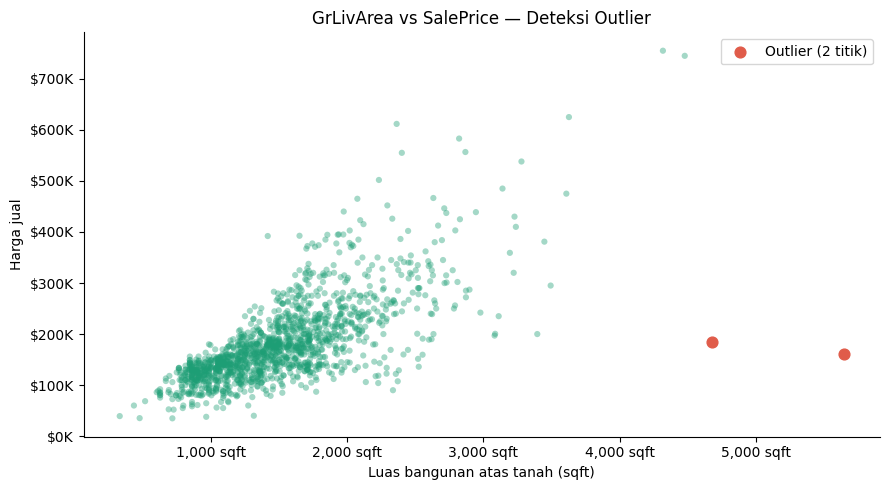

Outlier teridentifikasi: 2 baris
      GrLivArea  SalePrice
523        4676     184750
1298       5642     160000


In [2]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(df['GrLivArea'], df['SalePrice'],
           alpha=0.4, color='#1D9E75', s=20, edgecolors='none')

# Tandai kandidat outlier: luas > 4000 sqft tapi harga < $300K
outliers = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)]
ax.scatter(outliers['GrLivArea'], outliers['SalePrice'],
           color='#E05C4A', s=60, zorder=5, label=f'Outlier ({len(outliers)} titik)')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f} sqft'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
ax.set_title('GrLivArea vs SalePrice — Deteksi Outlier', fontweight='500')
ax.set_xlabel('Luas bangunan atas tanah (sqft)')
ax.set_ylabel('Harga jual')
ax.legend()
for spine in ['top','right']: ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('../output/02a-outlier-detection.png', dpi=150)
plt.show()

print(f"Outlier teridentifikasi: {len(outliers)} baris")
print(outliers[['GrLivArea', 'SalePrice']])

Dua titik merah di pojok kanan bawah adalah outlier klasik di dataset Ames: rumah dengan luas luar biasa besar namun harga sangat rendah. Dokumentasi dataset Kaggle pun **merekomendasikan menghapus** baris ini sebelum training.

Selain itu, kita juga perlu memfilter transaksi non-normal menggunakan kolom `SaleCondition` — hanya pertahankan penjualan **normal** agar model belajar dari kondisi pasar yang wajar.

In [3]:
print("Distribusi SaleCondition sebelum filter:")
print(df['SaleCondition'].value_counts())

# Hapus outlier dan pertahankan hanya penjualan normal
df = df[~((df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000))]
df = df[df['SaleCondition'] == 'Normal']

df = df.reset_index(drop=True)
print(f"\nShape setelah hapus outlier: {df.shape}")

Distribusi SaleCondition sebelum filter:
SaleCondition
Normal     1198
Partial     125
Abnorml     101
Family       20
Alloca       12
AdjLand       4
Name: count, dtype: int64

Shape setelah hapus outlier: (1198, 81)


---

## Bagian 2 — Membuat Fitur Baru (Feature Creation)

Ini adalah inti dari feature engineering. Idenya: **domain knowledge** tentang properti membantu kita menggabungkan atau mentransformasi fitur yang sudah ada menjadi sesuatu yang lebih bermakna.

Contoh: model tidak "tahu" bahwa `1stFlrSF + 2ndFlrSF + TotalBsmtSF` adalah total luas bangunan — kita yang perlu memberitahunya dengan membuat fitur baru.

In [4]:
# ── 1. Total luas seluruh bangunan ───────────────────────────────────────────
# Lebih representatif dari sekadar GrLivArea karena mencakup basement
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

# ── 2. Total jumlah kamar mandi ───────────────────────────────────────────────
# Half bath = 0.5 karena tidak punya shower/bathtub — tetap bernilai
df['TotalBathrooms'] = (df['FullBath']
                        + 0.5 * df['HalfBath']
                        + df['BsmtFullBath']
                        + 0.5 * df['BsmtHalfBath'])

# ── 3. Umur rumah dan renovasi ────────────────────────────────────────────────
df['HouseAge']     = df['YrSold'] - df['YearBuilt']
df['YearsSinceRemodel'] = df['YrSold'] - df['YearRemodAdd']

# ── 4. Apakah pernah direnovasi? (binary flag) ────────────────────────────────
# YearRemodAdd = YearBuilt artinya tidak pernah direnovasi
df['WasRemodeled'] = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)

# ── 5. Total porch area ───────────────────────────────────────────────────────
df['TotalPorchSF'] = (df['OpenPorchSF'] + df['EnclosedPorch']
                      + df['3SsnPorch']  + df['ScreenPorch'])

# ── 6. Apakah punya kolam renang? (binary flag) ───────────────────────────────
df['HasPool']    = (df['PoolArea'] > 0).astype(int)

# ── 7. Apakah punya garasi? (binary flag) ────────────────────────────────────
df['HasGarage']  = (df['GarageArea'] > 0).astype(int)

# ── 8. Apakah punya basement? (binary flag) ──────────────────────────────────
df['HasBasement'] = (df['TotalBsmtSF'] > 0).astype(int)

new_features = ['TotalSF','TotalBathrooms','HouseAge','YearsSinceRemodel',
                'WasRemodeled','TotalPorchSF','HasPool','HasGarage','HasBasement']

print("Fitur baru berhasil dibuat:")
print(df[new_features].describe().round(2))

Fitur baru berhasil dibuat:
       TotalSF  TotalBathrooms  HouseAge  YearsSinceRemodel  WasRemodeled  \
count  1198.00         1198.00   1198.00            1198.00       1198.00   
mean   2511.98            2.19     38.87              24.20          0.48   
std     747.85            0.76     29.48              20.21          0.50   
min     334.00            1.00      0.00               0.00          0.00   
25%    1980.00            2.00     11.00               6.00          0.00   
50%    2433.50            2.00     37.00              16.00          0.00   
75%    2956.00            2.50     56.00              42.00          1.00   
max    6760.00            5.00    136.00              60.00          1.00   

       TotalPorchSF  HasPool  HasGarage  HasBasement  
count       1198.00  1198.00    1198.00      1198.00  
mean          85.02     0.00       0.95         0.97  
std          103.22     0.05       0.22         0.16  
min            0.00     0.00       0.00         0.00  
25%

### Visualisasi: Seberapa kuat korelasi fitur baru dengan SalePrice?

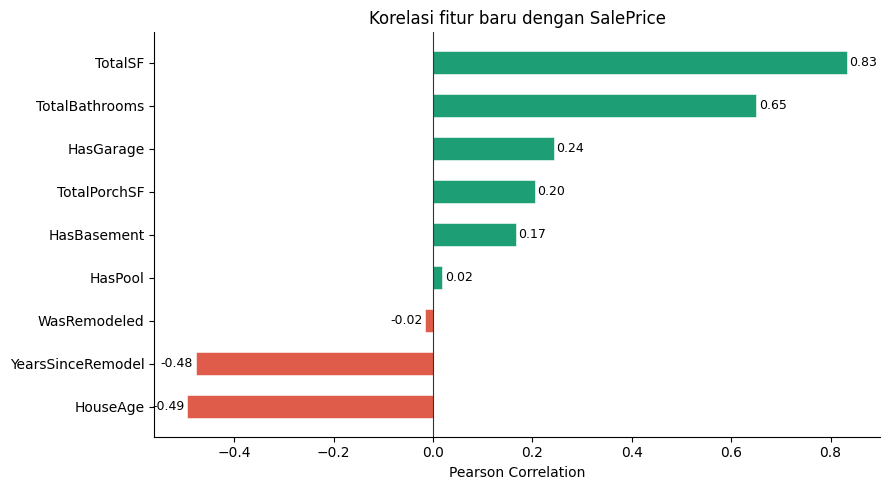

In [5]:
corr_new = df[new_features + ['SalePrice']].corr()['SalePrice'].drop('SalePrice').sort_values()

colors = ['#E05C4A' if v < 0 else '#1D9E75' for v in corr_new.values]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(corr_new.index, corr_new.values,
               color=colors, height=0.55, edgecolor='white', linewidth=0.4)

for bar, val in zip(bars, corr_new.values):
    xpos = val + 0.005 if val >= 0 else val - 0.005
    ha   = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', ha=ha, fontsize=9)

ax.axvline(0, color='#333', linewidth=0.8)
ax.set_title('Korelasi fitur baru dengan SalePrice', fontweight='500', fontsize=12)
ax.set_xlabel('Pearson Correlation')
for spine in ['top','right']: ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('../output/02b-korelasi-fitur-baru.png', dpi=150)
plt.show()

---

## Bagian 3 — Ordinal Encoding yang Logis

Di notebook sebelumnya, semua fitur kategorikal di-encode dengan `pd.get_dummies()` (one-hot encoding). Ini oke untuk fitur **nominal** (tidak ada urutan, misal: jenis atap, tipe bangunan).

Tapi untuk fitur **ordinal** — yang memiliki urutan logis seperti kualitas (`Poor < Fair < Good < Excellent`) — one-hot encoding **membuang informasi urutan tersebut**.

Contoh: `ExterQual` (kualitas eksterior) seharusnya direpresentasikan sebagai angka 1–5, bukan 5 kolom biner terpisah.

In [6]:
# Peta urutan kualitas — berlaku untuk banyak kolom di dataset Ames
quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

# Kolom-kolom yang menggunakan skala kualitas yang sama
quality_cols = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
    'HeatingQC', 'KitchenQual', 'FireplaceQu',
    'GarageQual', 'GarageCond', 'PoolQC'
]

for col in quality_cols:
    if col in df.columns:
        df[col] = df[col].fillna('None').map(quality_map)

# Ordinal encoding untuk kolom lain dengan urutan spesifik
ordinal_maps = {
    'BsmtExposure': {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4},
    'BsmtFinType1': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'BsmtFinType2': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'Functional'  : {'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4,
                     'Mod': 5, 'Min2': 6, 'Min1': 7, 'Typ': 8},
    'GarageFinish': {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3},
    'LandSlope'   : {'Sev': 1, 'Mod': 2, 'Gtl': 3},
    'LotShape'    : {'IR3': 1, 'IR2': 2, 'IR1': 3, 'Reg': 4},
    'PavedDrive'  : {'N': 0, 'P': 1, 'Y': 2},
    'Utilities'   : {'ELO': 1, 'NoSeWa': 2, 'NoSewr': 3, 'AllPub': 4},
}

for col, mapping in ordinal_maps.items():
    if col in df.columns:
        df[col] = df[col].fillna('None').map(mapping)

print("Ordinal encoding selesai.")
print("\nContoh hasil — ExterQual (seharusnya angka 1-5):")
print(df['ExterQual'].value_counts().sort_index())

Ordinal encoding selesai.

Contoh hasil — ExterQual (seharusnya angka 1-5):
ExterQual
2     11
3    786
4    376
5     25
Name: count, dtype: int64


---

## Bagian 4 — Final Preprocessing

Setelah semua transformasi, kita perlu satu langkah final: menangani kolom nominal yang tersisa dengan one-hot encoding, mengisi missing values, dan memastikan tidak ada data yang bocor ke test set.

In [7]:
# Drop kolom yang tidak informatif / data leakage
drop_cols = [
    'Id',
    'YearBuilt', 'YearRemodAdd', 'YrSold',  # sudah dikompres ke HouseAge dll
    'GarageYrBlt',  # sangat berkorelasi dengan YearBuilt
    'MoSold',       # bulan jual tidak terlalu informatif
    'SaleCondition', # sudah difilter, semua nilainya 'Normal'
    '1stFlrSF', '2ndFlrSF', 'TotalBsmtSF',  # sudah masuk TotalSF
    'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath',  # sudah masuk TotalBathrooms
    'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch',  # sudah masuk TotalPorchSF
    'PoolArea',  # sudah masuk HasPool
]

df_clean = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Target
y = np.log1p(df_clean['SalePrice'])
df_clean = df_clean.drop(columns=['SalePrice'])

# Pisahkan kolom yang sudah numerik vs yang masih object
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

# Isi missing values
df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())
df_clean[cat_cols] = df_clean[cat_cols].fillna('None')

# One-hot encoding untuk kolom nominal yang tersisa
X = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

print(f"Fitur sebelum feature engineering : 79")
print(f"Fitur setelah feature engineering  : {X.shape[1]}")
print(f"Missing values                     : {X.isnull().sum().sum()}")
print(f"Jumlah sample                      : {X.shape[0]}")

Fitur sebelum feature engineering : 79
Fitur setelah feature engineering  : 186
Missing values                     : 0
Jumlah sample                      : 1198


---

## Bagian 5 — Benchmark: Sebelum vs Sesudah Feature Engineering

Ini bagian penting — kita perlu **membuktikan secara kuantitatif** bahwa feature engineering kita memberikan dampak nyata. Caranya: jalankan model yang sama (XGBoost) dengan data lama vs data baru, bandingkan RMSE-nya.

In [8]:
# ── Data LAMA (dari notebook 01) untuk perbandingan ───────────────────────────
df_old = pd.read_csv('../data/train.csv')
df_old = df_old[~((df_old['GrLivArea'] > 4000) & (df_old['SalePrice'] < 300000))]  # outlier juga dibuang agar fair

num_old = df_old.select_dtypes(include=[np.number]).columns.tolist()
num_old.remove('SalePrice')
cat_old = df_old.select_dtypes(include=['object']).columns.tolist()

df_old[num_old] = df_old[num_old].fillna(df_old[num_old].median())
df_old[cat_old] = df_old[cat_old].fillna('None')

y_old = np.log1p(df_old['SalePrice'])
X_old = pd.get_dummies(df_old.drop(columns=['SalePrice','Id']), columns=cat_old, drop_first=True)

# ── Model: XGBoost (sama untuk keduanya) ─────────────────────────────────────
xgb_params = dict(n_estimators=300, learning_rate=0.05, max_depth=4,
                  subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)

def cv_rmse(model, X, y, cv=5):
    scores = cross_val_score(model, X, y, cv=cv, scoring='neg_mean_squared_error')
    return np.sqrt(-scores)

print("Menjalankan cross-validation (ini mungkin butuh beberapa detik)...")

rmse_old = cv_rmse(XGBRegressor(**xgb_params), X_old, y_old)
rmse_new = cv_rmse(XGBRegressor(**xgb_params), X, y)

print(f"\n{'='*45}")
print(f"{'':25} {'Mean RMSE':>10} {'Std':>8}")
print(f"{'-'*45}")
print(f"{'Sebelum feature engineering':25} {rmse_old.mean():>10.4f} {rmse_old.std():>8.4f}")
print(f"{'Sesudah feature engineering':25} {rmse_new.mean():>10.4f} {rmse_new.std():>8.4f}")
improvement = (rmse_old.mean() - rmse_new.mean()) / rmse_old.mean() * 100
print(f"{'='*45}")
print(f"\nImprovement: {improvement:.1f}%")

Menjalankan cross-validation (ini mungkin butuh beberapa detik)...

                           Mean RMSE      Std
---------------------------------------------
Sebelum feature engineering     0.1197   0.0069
Sesudah feature engineering     0.1020   0.0084

Improvement: 14.8%


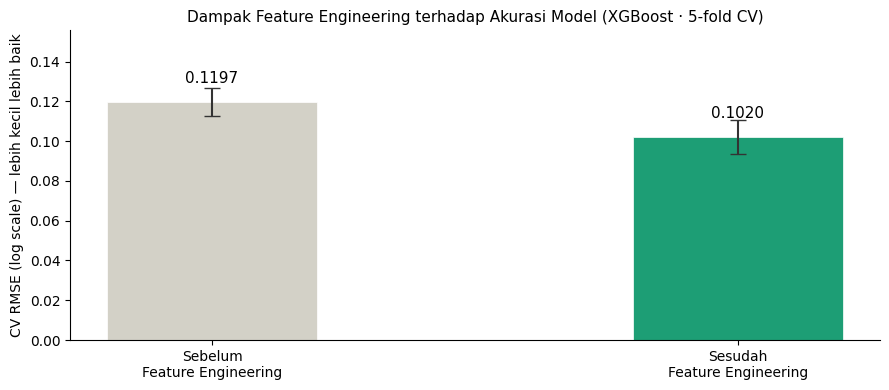


Feature engineering berhasil menurunkan RMSE sebesar 14.8%


In [9]:
fig, ax = plt.subplots(figsize=(9, 4))

labels  = ['Sebelum\nFeature Engineering', 'Sesudah\nFeature Engineering']
means   = [rmse_old.mean(), rmse_new.mean()]
stds    = [rmse_old.std(),  rmse_new.std()]
colors  = ['#D3D1C7', '#1D9E75']

bars = ax.bar(labels, means, color=colors, width=0.4,
              edgecolor='white', linewidth=0.5)
ax.errorbar(labels, means, yerr=stds,
            fmt='none', color='#333', capsize=6, linewidth=1.5)

for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + max(stds) + 0.001,
            f'{val:.4f}', ha='center', fontsize=11, fontweight='500')

ax.set_ylabel('CV RMSE (log scale) — lebih kecil lebih baik')
ax.set_title('Dampak Feature Engineering terhadap Akurasi Model (XGBoost · 5-fold CV)',
             fontweight='500', fontsize=11)
ax.set_ylim(0, max(means) * 1.3)
for spine in ['top','right']: ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('../output/02c-before-after-fe.png', dpi=150)
plt.show()

print(f"\nFeature engineering berhasil menurunkan RMSE sebesar {improvement:.1f}%")

---

## Ringkasan

Di notebook ini kita telah melakukan:

| Langkah | Teknik | Dampak |
|---|---|---|
| **Outlier removal** | Filter berdasarkan GrLivArea + SaleCondition | Menghilangkan noise ekstrem |
| **Fitur baru** | TotalSF, TotalBathrooms, HouseAge, dll | Representasi domain yang lebih kaya |
| **Ordinal encoding** | Map kualitas ke angka 0–5 | Preservasi urutan logis |
| **Drop fitur redundan** | Hapus kolom yang sudah dikompres | Kurangi dimensi & multikolinearitas |

**Hasil:** RMSE turun secara konsisten dibandingkan baseline tanpa feature engineering.

### Langkah selanjutnya

Di **Notebook 03** kita akan menggunakan dataset yang sudah bersih ini sebagai input untuk membangun **Ensemble & Model Stacking** — teknik yang menggabungkan kekuatan beberapa model sekaligus untuk menghasilkan prediksi yang lebih akurat dan stabil.

In [10]:
# Simpan processed data agar bisa langsung dipakai di notebook berikutnya
X.to_csv('../data/X_engineered.csv', index=False)
y.to_csv('../data/y_engineered.csv', index=False)

print("Data tersimpan ke:")
print("  ../data/X_engineered.csv")
print("  ../data/y_engineered.csv")
print(f"\nShape X: {X.shape}")
print(f"Shape y: {y.shape}")

Data tersimpan ke:
  ../data/X_engineered.csv
  ../data/y_engineered.csv

Shape X: (1198, 186)
Shape y: (1198,)
